# Phase 1 & 2: Exploratory Data Analysis & Feature Benchmark
## Project: AI-Powered Alternative Credit Assessment for Thin-File Borrowers

This notebook demonstrates:
1. Target variable distribution & default imbalance.
2. Subpopulation split: **Thin-File vs. Thick-File Applicants**.
3. Feature distributions across **Traditional** and **Alternative** modalities.
4. Benchmarking the 9 ML experiments (Traditional vs Alternative vs Combined).

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)

# Load cleaned feature sample
DATA_PATH = '../data/processed/cleaned_features_sample.csv'
df = pd.read_csv(DATA_PATH)
print(f"Loaded Sample Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/cleaned_features_sample.csv'

## 1. Target Imbalance Analysis

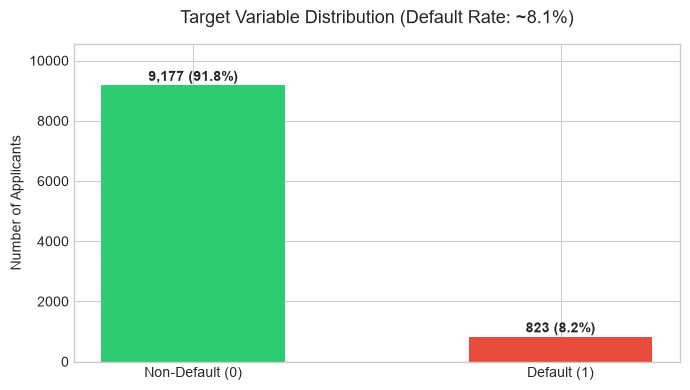

In [ ]:
plt.figure(figsize=(7, 4))
counts = df['TARGET'].value_counts()
labels = ['Non-Default (0)', 'Default (1)']
colors = ['#2ecc71', '#e74c3c']

plt.bar(labels, counts, color=colors, width=0.5)
for i, val in enumerate(counts):
    pct = (val / len(df)) * 100
    plt.text(i, val + 150, f"{val:,} ({pct:.1f}%)", ha='center', fontweight='bold')

plt.title('Target Variable Distribution (Default Rate: ~8.1%)', fontsize=13, pad=15)
plt.ylabel('Number of Applicants')
plt.ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.show()

## 2. Thin-File Subpopulation Analysis
Borrowers with zero or missing credit bureau inquiries in the past year.

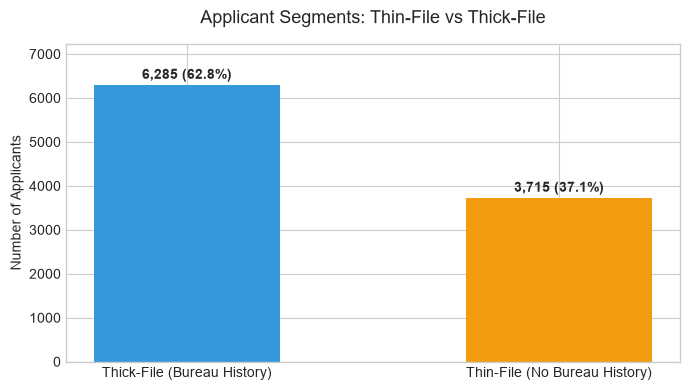

In [ ]:
plt.figure(figsize=(7, 4))
tf_counts = df['IS_THIN_FILE'].value_counts()
tf_labels = ['Thick-File (Bureau History)', 'Thin-File (No Bureau History)']

plt.bar(tf_labels, tf_counts, color=['#3498db', '#f39c12'], width=0.5)
for i, val in enumerate(tf_counts):
    pct = (val / len(df)) * 100
    plt.text(i, val + 150, f"{val:,} ({pct:.1f}%)", ha='center', fontweight='bold')

plt.title('Applicant Segments: Thin-File vs Thick-File', fontsize=13, pad=15)
plt.ylabel('Number of Applicants')
plt.ylim(0, max(tf_counts) * 1.15)
plt.tight_layout()
plt.show()

## 3. Alternative Scores (`EXT_SOURCE_1/2/3`) by Default Status
Shows how non-traditional external proxy scores separate defaulters from non-defaulters.

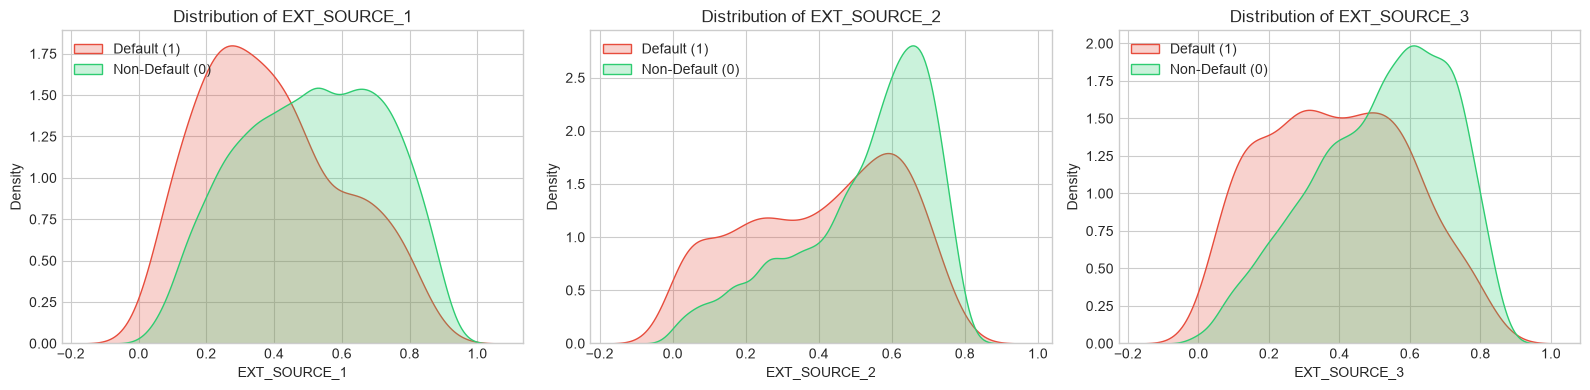

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sources = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

for ax, src in zip(axes, sources):
    sns.kdeplot(data=df, x=src, hue='TARGET', common_norm=False, fill=True, palette=['#2ecc71', '#e74c3c'], ax=ax)
    ax.set_title(f'Distribution of {src}', fontsize=12)
    ax.legend(['Default (1)', 'Non-Default (0)'], loc='upper left')

plt.tight_layout()
plt.show()

## 4. Benchmark Performance Across 9 Experiments (Research Paper 1)

,Feature Set,Model,Overall ROC-AUC,Thin-File ROC-AUC,Overall F1,Thin-File F1
0,Traditional,Logistic Regression,0.6503,0.6596,0.1993,0.2048
1,Traditional,Random Forest,0.6711,0.6812,0.2161,0.2244
2,Traditional,XGBoost,0.6969,0.7046,0.0869,0.1128
3,Alternative,Logistic Regression,0.7297,0.7203,0.2492,0.2435
4,Alternative,Random Forest,0.7315,0.7245,0.2558,0.2489
5,Alternative,XGBoost,0.7357,0.7299,0.1920,0.1860
6,Combined,Logistic Regression,0.7436,0.7397,0.2554,0.2545
7,Combined,Random Forest,0.7475,0.7456,0.2660,0.2655
8,Combined,XGBoost,0.7614,0.7625,0.2537,0.2603


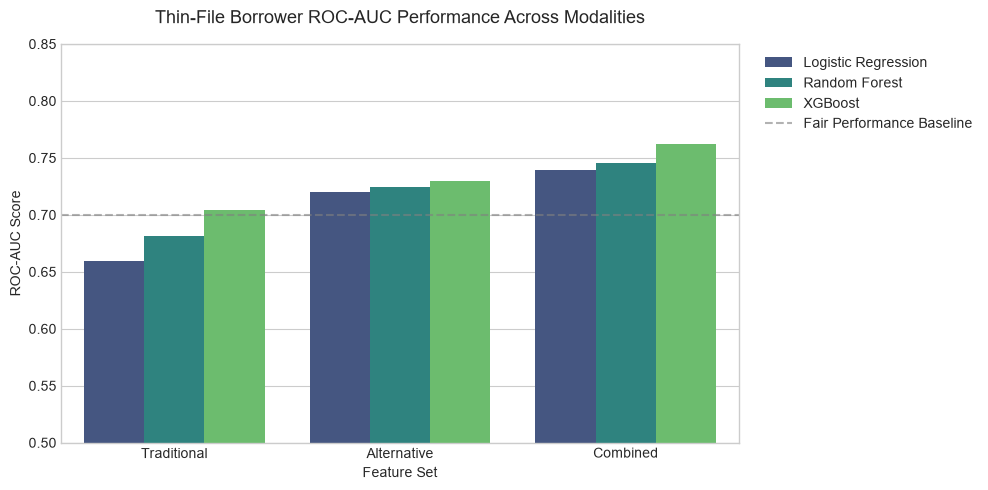

In [ ]:
results_path = '../results/benchmark_results.csv'
if os.path.exists(results_path):
    results_df = pd.read_csv(results_path)
    display(results_df[['Feature Set', 'Model', 'Overall ROC-AUC', 'Thin-File ROC-AUC', 'Overall F1', 'Thin-File F1']])
    
    # Bar Plot for ROC-AUC Comparison
    plt.figure(figsize=(10, 5))
    sns.barplot(data=results_df, x='Feature Set', y='Thin-File ROC-AUC', hue='Model', palette='viridis')
    plt.title('Thin-File Borrower ROC-AUC Performance Across Modalities', fontsize=13, pad=15)
    plt.ylabel('ROC-AUC Score')
    plt.ylim(0.5, 0.85)
    plt.axhline(0.70, color='gray', linestyle='--', alpha=0.6, label='Fair Performance Baseline')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("Run train.py first to produce benchmark results.")